In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/subashgandyer/datasets/main/loan_train.csv"
df = pd.read_csv(url)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.isnull().mean() * 100

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


In [4]:
df.shape

(614, 13)

In [5]:
#extracting columns with less than 5% missing values
cols = [var for var in df.columns
        if 0 < df[var].isnull().mean() < 0.05]
cols

['Gender', 'Married', 'Dependents', 'LoanAmount', 'Loan_Amount_Term']

In [6]:
df[cols].sample(5)

,Gender,Married,Dependents,LoanAmount,Loan_Amount_Term
423,Male,Yes,1,110.0,NaN
278,Male,Yes,0,436.0,360.0
442,Male,No,3+,148.0,360.0
224,Male,Yes,0,128.0,360.0
280,Male,No,1,158.0,360.0


In [7]:
len(df[cols].dropna()) / len(df)

0.9006514657980456

In [8]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((614, 13), (553, 5))

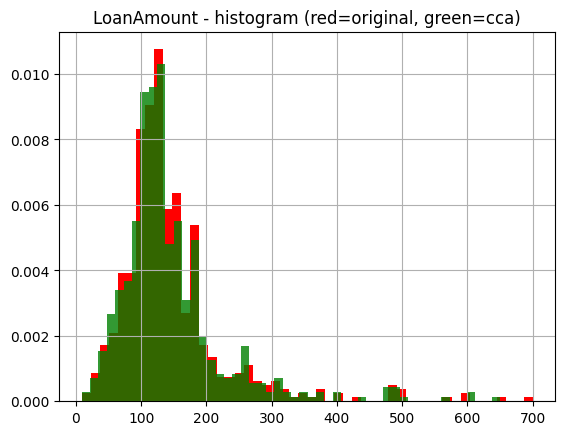

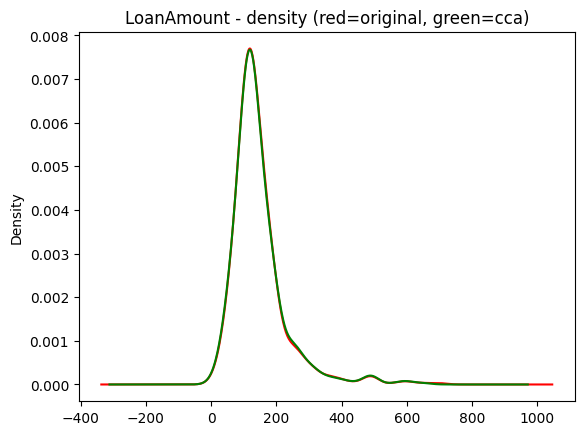

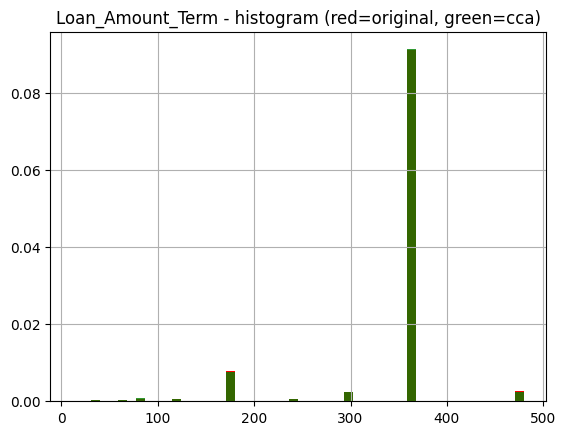

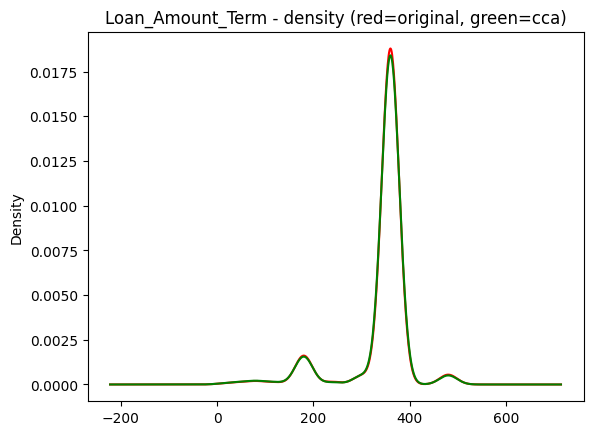

In [9]:
numerical = ['LoanAmount', 'Loan_Amount_Term']

for col in numerical:
    # --- histogram overlay ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    df[col].hist(bins=50, ax=ax, density=True, color='red')                       # original
    new_df[col].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)      # after cca
    ax.set_title(f'{col} - histogram (red=original, green=cca)')
    plt.show()

    # --- density (KDE) overlay ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    df[col].plot.density(color='red')        # original
    new_df[col].plot.density(color='green')  # after cca
    ax.set_title(f'{col} - density (red=original, green=cca)')
    plt.show()

In [10]:
categorical = ['Gender', 'Married', 'Dependents']

for col in categorical:
    temp = pd.concat([
        df[col].value_counts() / len(df),          # proportion, original data
        new_df[col].value_counts() / len(new_df)    # proportion, cca data
    ], axis=1)
    temp.columns = ['original', 'cca']
    print(f'\n--- {col} ---')
    print(temp)


--- Gender ---
        original       cca
Gender                    
Male    0.796417  0.811935
Female  0.182410  0.188065

--- Married ---
         original       cca
Married                    
Yes      0.648208  0.649186
No       0.346906  0.350814

--- Dependents ---
            original       cca
Dependents                    
0           0.561889  0.571429
1           0.166124  0.173599
2           0.164495  0.173599
3+          0.083062  0.081374
